<a href="https://colab.research.google.com/github/DevAnand-debugger/Class-mini-project/blob/main/Copy_of_MINIPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDP MINI PROJECT


### Objective:

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Retail Sales Transactions dataset to uncover meaningful patterns, trends, and relationships within the data. The analysis focuses on understanding sales performance across product categories, identifying customer purchasing behavior based on demographic attributes, and analyzing temporal trends to detect variations over time.

### Justification:

This dataset is well-suited for analysis as it contains a combination of transactional, demographic, and product-related features. These attributes enable comprehensive analysis of sales distribution, customer segmentation, and revenue patterns, making it ideal for deriving actionable business insights and supporting data-driven decision-making.


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd              # Data manipulation
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced visualization

# Improve visualization aesthetics
sns.set(style="whitegrid")

print("Libraries Imported Successfully ")

Libraries Imported Successfully 


In [ ]:
# ==============================
#  LOAD DATASET
# ==============================

from google.colab import files
uploaded = files.upload()

# Read dataset (ensure filename matches)
df = pd.read_csv('/content/edab.csv')

# Display first 5 rows
df.head()

Saving edab.csv to edab (4).csv


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [ ]:


# Date Preprocessing
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# Extracting Time-based features
df['Month'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.day_name()

# Creating Age Bins (Demographic Segmentation)
bins = [0, 25, 45, 100]
labels = ['Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Creating a Spending Efficiency feature
df['Price_Per_Item'] = df['Total Amount'] / df['Quantity']

print("New features 'Month', 'AgeGroup', and 'Price_Per_Item' added successfully.")

New features 'Month', 'AgeGroup', and 'Price_Per_Item' added successfully.


In [ ]:
# ==============================
#  DATA UNDERSTANDING
# ==============================

print("Shape of Dataset:", df.shape)
print(" Column Names:\n", df.columns)

print(" Data Types & Info:")
df.info()


Shape of Dataset: (1000, 13)
 Column Names:
 Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Weekday', 'AgeGroup', 'Price_Per_Item'],
      dtype='object')
 Data Types & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month       

In [ ]:
# ==============================
#  DATA CLEANING
# ==============================

# Check missing values
print("Missing Values:\n", df.isnull().sum())



Missing Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Month               0
Weekday             0
AgeGroup            0
Price_Per_Item      0
dtype: int64


In [ ]:
# Drop missing values
df = df.dropna()

In [ ]:
# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

print("\n Data Cleaning Completed")


 Data Cleaning Completed


In [ ]:
# ==============================
#  FEATURE ENGINEERING
# ==============================

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

print(" Feature Engineering Done")#we wrote this to ensure code is executed

 Feature Engineering Done


In [ ]:
# ==============================
#  BASIC STATISTICS
# ==============================

total_sales = df['Total Amount'].sum()
avg_sales = df['Total Amount'].mean()
min_sales = df['Total Amount'].min()
max_sales = df['Total Amount'].max()

print(f"Total Sales: {total_sales}")
print(f"Average Sales: {avg_sales}")
print(f"Minimum Sales: {min_sales}")
print(f"Maximum Sales: {max_sales}")

Total Sales: 456000
Average Sales: 456.0
Minimum Sales: 25
Maximum Sales: 2000


In [ ]:
# ==============================
#  GROUPED ANALYSIS
# ==============================

# Category-wise sales
category_sales = df.groupby('Product Category')['Total Amount'].sum()

# Gender-wise sales
gender_sales = df.groupby('Gender')['Total Amount'].sum()

# Monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()

print("Category Sales:\n", category_sales)
print("\nGender Sales:\n", gender_sales)

Category Sales:
 Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

Gender Sales:
 Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


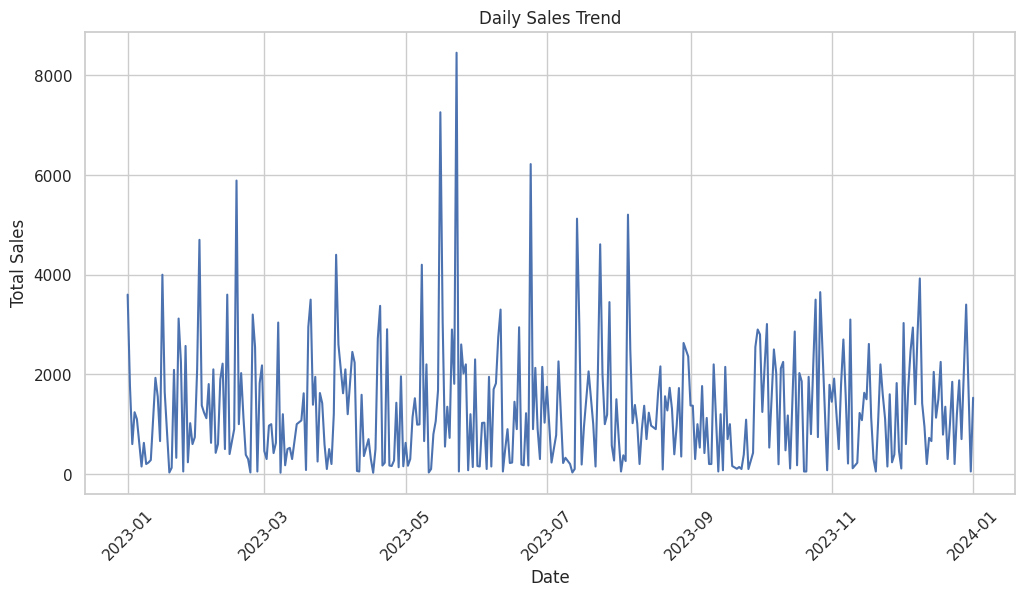

In [ ]:
# ==============================
# TIME SERIES ANALYSIS
# ==============================

# Daily Sales Trend
daily_sales = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()



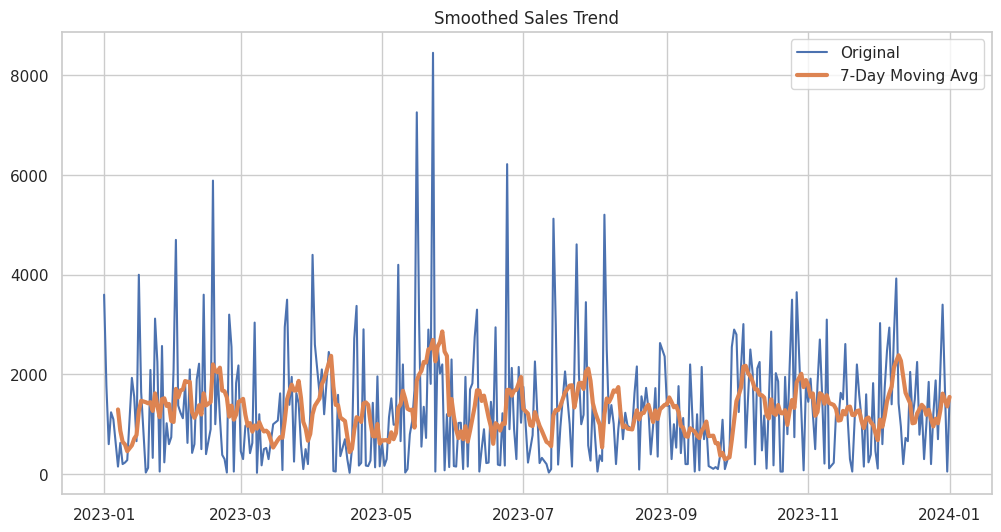

In [ ]:
# Moving Average (Smoothing)
sales_ma = daily_sales.rolling(7).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_sales, label='Original')
plt.plot(sales_ma, label='7-Day Moving Avg', linewidth=3)
plt.legend()
plt.title("Smoothed Sales Trend")
plt.show()

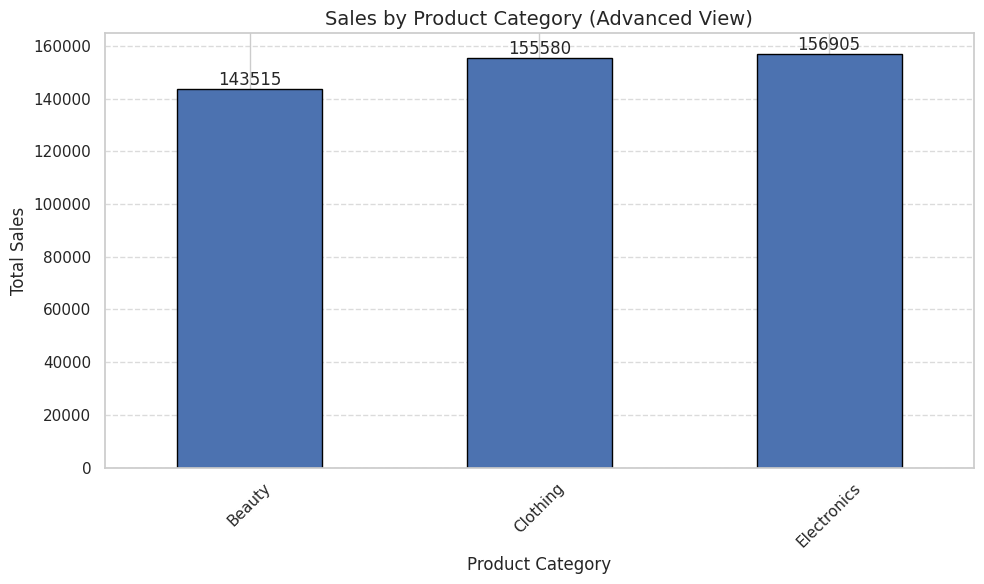

In [ ]:
#BAR CHART


plt.figure(figsize=(10,6))

bars = category_sales.plot(
    kind='bar',
    edgecolor='black'
)

# Add value labels on top
for i, v in enumerate(category_sales):
    plt.text(i, v, str(round(v, 1)), ha='center', va='bottom')

plt.title("Sales by Product Category (Advanced View)", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

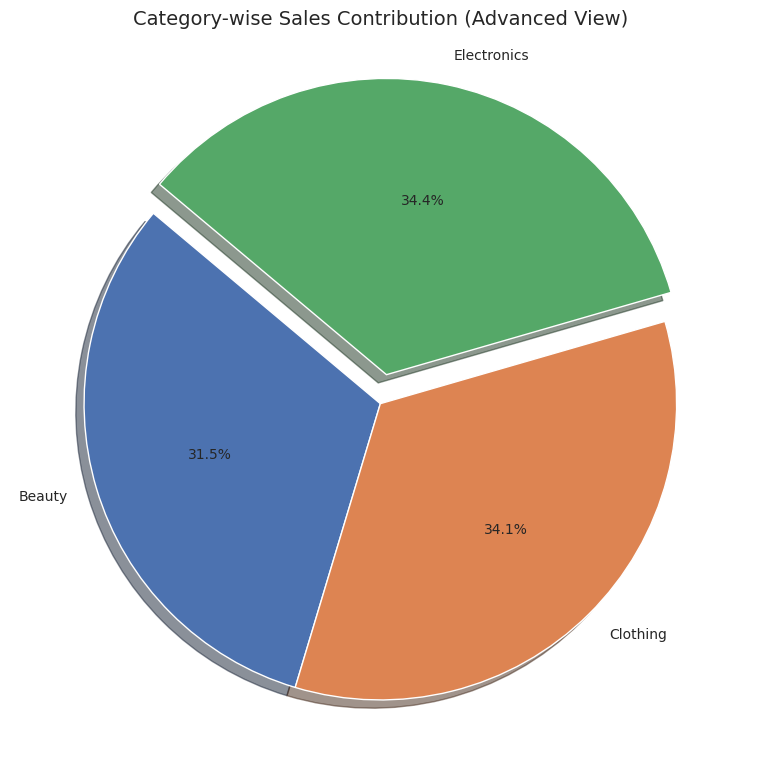

In [ ]:
# PIE CHART
plt.figure(figsize=(8,8))

# Explode only the highest value
explode = [0.1 if v == category_sales.max() else 0 for v in category_sales]

wedges, texts, autotexts = plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    explode=explode,
    shadow=True,
    startangle=140
)

# Improve text readability
for text in texts:
    text.set_fontsize(10)

for autotext in autotexts:
    autotext.set_fontsize(10)

plt.title("Category-wise Sales Contribution (Advanced View)", fontsize=14)

plt.tight_layout()
plt.show()

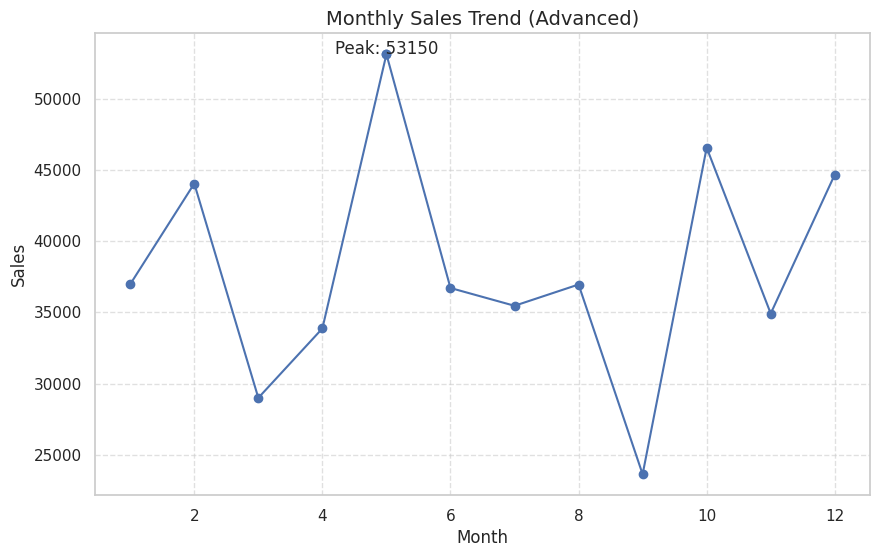

In [ ]:
# ==============================
# LINE CHART
# ==============================

plt.figure(figsize=(10,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linestyle='-'
)

# Highlight max point
max_val = monthly_sales.max()
max_month = monthly_sales.idxmax()

plt.scatter(max_month, max_val)
plt.text(max_month, max_val, f"Peak: {max_val}", ha='center')

plt.title("Monthly Sales Trend (Advanced)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True, linestyle='--', alpha=0.6)


plt.show()

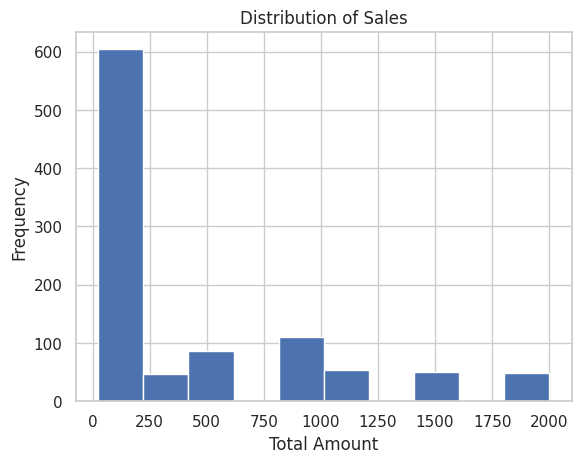

In [ ]:
plt.figure()
plt.hist(df['Total Amount'])
plt.title("Distribution of Sales")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ==============================
#  BASIC STATISTICS
# ==============================

total_sales = df['Total Amount'].sum()
avg_sales = df['Total Amount'].mean()
min_sales = df['Total Amount'].min()
max_sales = df['Total Amount'].max()

print(f"Total Sales: {total_sales}")
print(f"Average Sales: {avg_sales}")
print(f"Minimum Sales: {min_sales}")
print(f"Maximum Sales: {max_sales}")

Total Sales: 456000
Average Sales: 456.0
Minimum Sales: 25
Maximum Sales: 2000


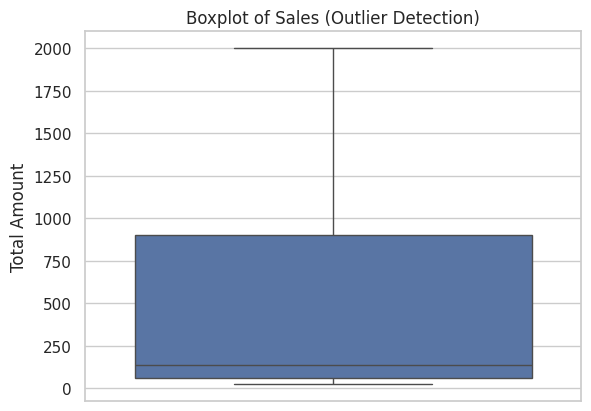

In [ ]:
plt.figure()
sns.boxplot(df['Total Amount'])
plt.title("Boxplot of Sales (Outlier Detection)")
plt.show()

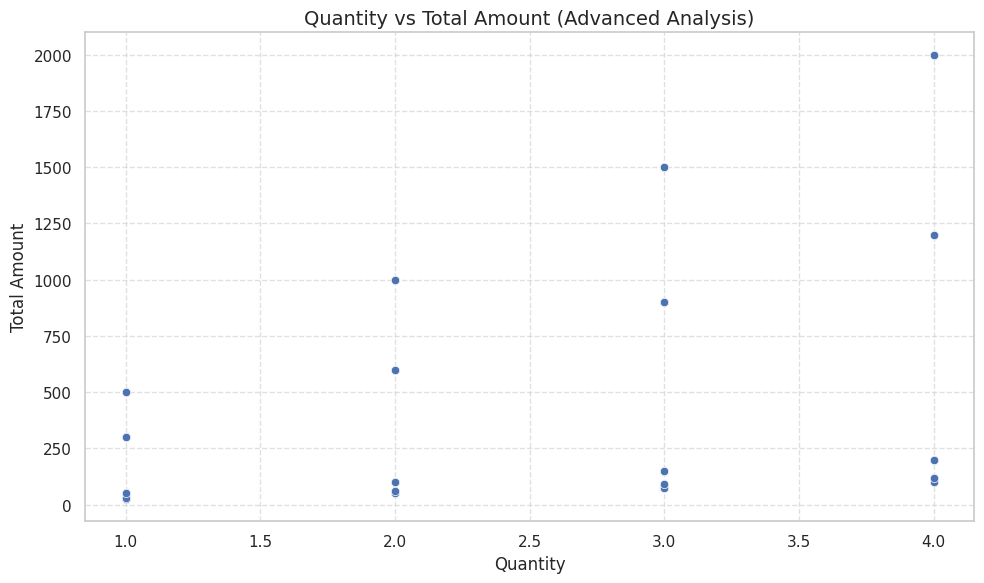

In [ ]:
# ==============================
#SCATTER PLOT
# ==============================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Quantity',
    y='Total Amount',
    data=df
)

plt.title("Quantity vs Total Amount (Advanced Analysis)", fontsize=14)
plt.xlabel("Quantity")
plt.ylabel("Total Amount")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

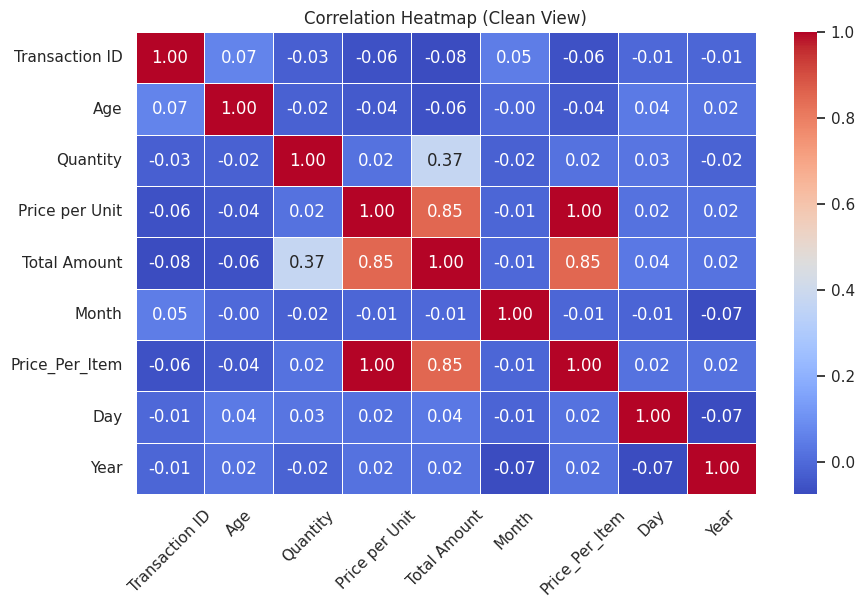

In [ ]:


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix (only numeric columns)
corr = df.corr(numeric_only=True)

# Set figure size (VERY IMPORTANT)
plt.figure(figsize=(10, 6))

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",              # reduce decimals
    cmap="coolwarm",        # better color
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap (Clean View)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

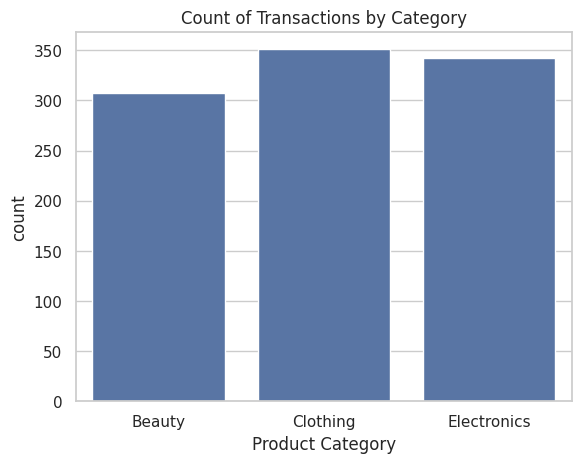

In [ ]:
plt.figure()
sns.countplot(x='Product Category', data=df)
plt.title("Count of Transactions by Category")
plt.show()

Gender            Female   Male
Product Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170


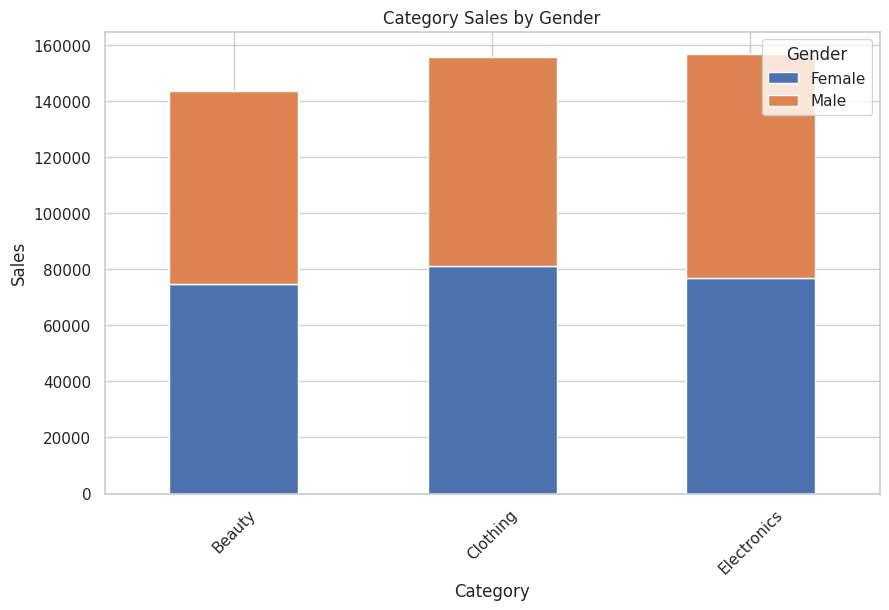

In [ ]:
# ==============================
# PIVOT TABLE
# ==============================

pivot = pd.pivot_table(
    df,
    values='Total Amount',
    index='Product Category',
    columns='Gender',
    aggfunc='sum'
)

print(pivot)

# ==============================
# STACKED BAR CHART
# ==============================
pivot.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Category Sales by Gender")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.show()

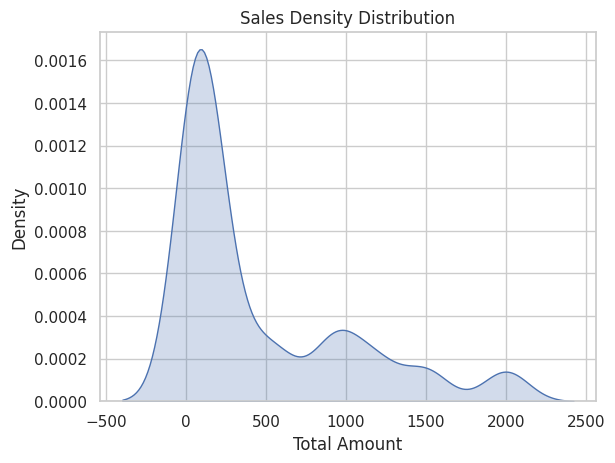

In [ ]:
# ==============================
# KDE PLOT (ADVANCED)
# ==============================

sns.kdeplot(df['Total Amount'], fill=True)

plt.title("Sales Density Distribution")
plt.xlabel("Total Amount")
plt.show()

/tmp/ipykernel_32142/1848056570.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AgeGroup', y='Total Amount', palette='Set2')


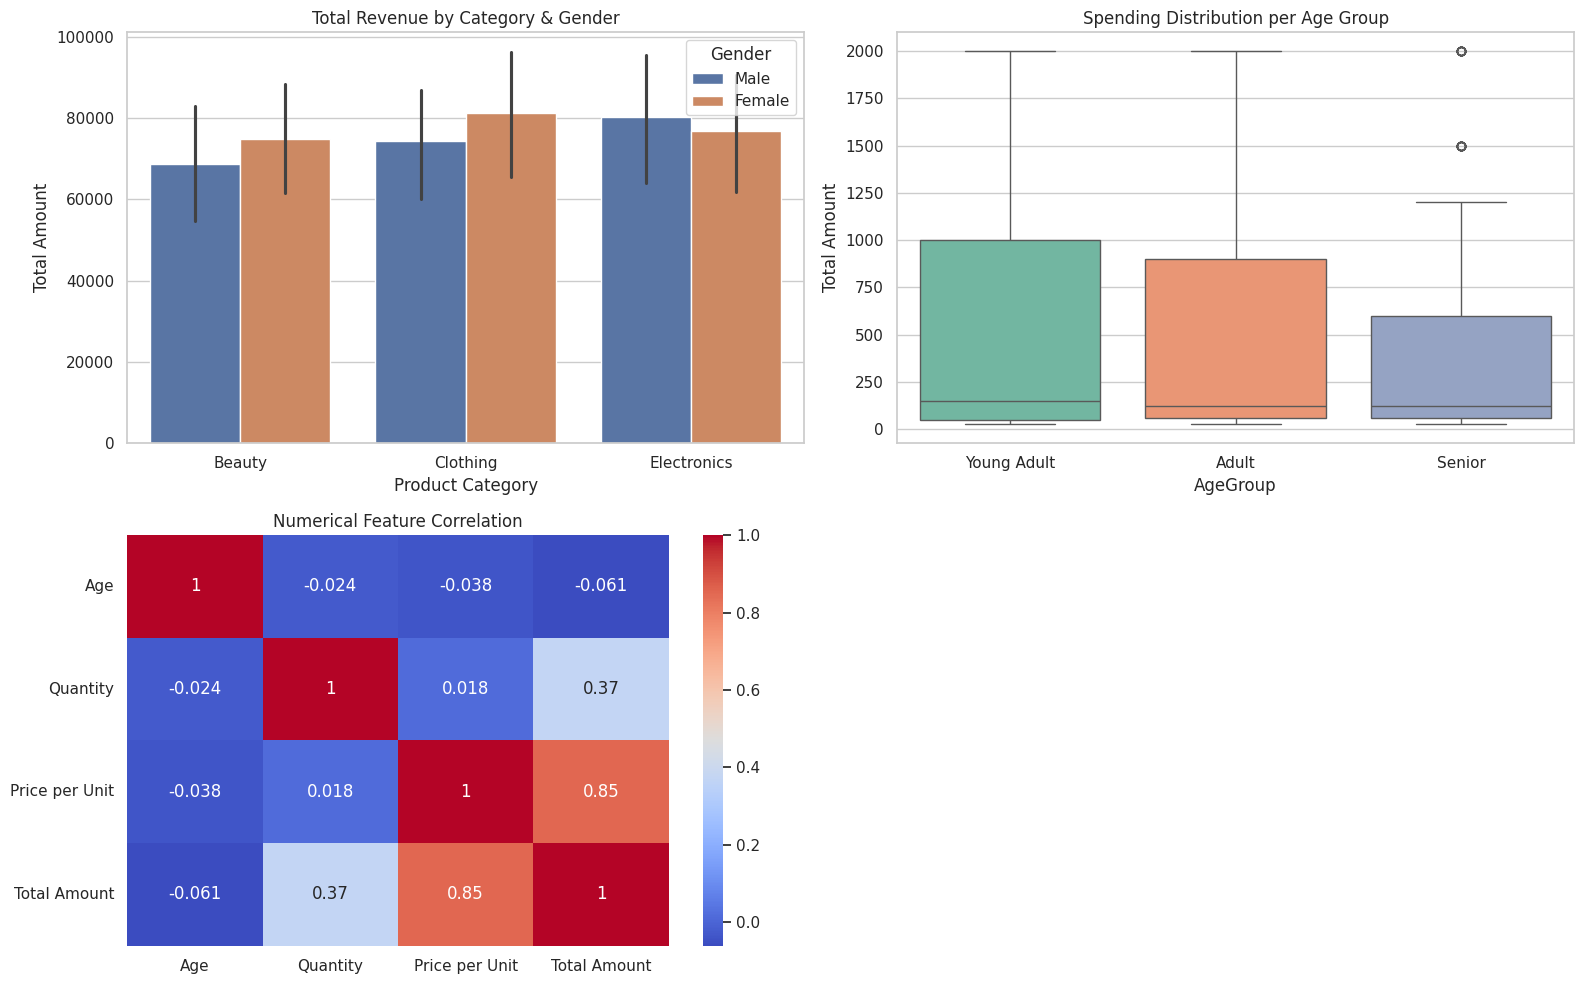

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

# Experiment 1: Revenue by Product Category & Gender
plt.subplot(2, 2, 1)
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender', estimator=sum)
plt.title('Total Revenue by Category & Gender')

# Experiment 2: Spending Pattern by Age Group
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='AgeGroup', y='Total Amount', palette='Set2')
plt.title('Spending Distribution per Age Group')

# Experiment 3: Correlation Matrix [Technical Insight]
plt.subplot(2, 2, 3)
sns.heatmap(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Feature Correlation')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# INSIGHTS
# ==============================

print("Top Category:", category_sales.idxmax())
print("Least Category:", category_sales.idxmin())

print("Best Month:", monthly_sales.idxmax())
print("Worst Month:", monthly_sales.idxmin())

Top Category: Electronics
Least Category: Beauty
Best Month: 5
Worst Month: 9


In [ ]:
pivot = pd.pivot_table(
    df,
    values='Total Amount',
    index='Product Category',
    columns='Gender',
    aggfunc='sum'
)

print(pivot)

Gender            Female   Male
Product Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170
